# `jax_phase_separation` demo

Small 8-component run showing matrix generation, stability analysis, simulation snapshots, phase identification, a movie, and a simple JAX gradient.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from jax_phase_separation.utils import (
    generate_chi_matrix, generate_initial_conditions, build_params,
    plot_volume_fractions, plot_phase_map, plot_partition_ratios,
)
from jax_phase_separation.solver import simulate, simulate_with_snapshots
from jax_phase_separation.free_energy import (
    compute_jacobian, stability_analysis, free_energy_density,
)
from jax_phase_separation.analysis import analyse_snapshot

print('JAX version:', jax.__version__)
print('Devices:', jax.devices())

JAX version: 0.6.0
Devices: [CpuDevice(id=0)]


## 1. Setup

Use an 8-component mixture on a 64x64 periodic grid.

In [2]:
N_COM = 8
N_GRID = 64
SIGMA = 4.8
BETA = N_COM / (N_COM + 1.0)
DT = 5e-6
LMBDA = 0.01
N_STEPS = 50_000
SAVE_EVERY = 5_000

key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)

## 2. Interaction matrix and stability analysis

`generate_chi_matrix` draws a symmetric random matrix with zero diagonal.
The Hessian of the free energy at the uniform state tells us how many
modes are linearly unstable (negative eigenvalues → demixing directions).

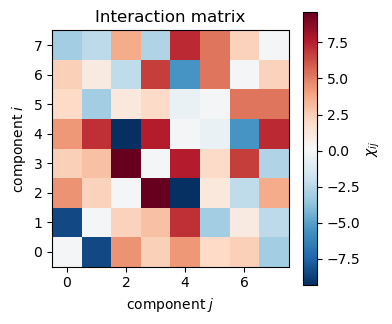

In [3]:
chi = generate_chi_matrix(N_COM, chi_mean=0.0, chi_std=SIGMA, key=k1)

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(chi, cmap='RdBu_r', origin='lower')
plt.colorbar(im, ax=ax, label=r'$\chi_{ij}$')
ax.set_title('Interaction matrix')
ax.set_xlabel('component $j$')
ax.set_ylabel('component $i$')
fig.tight_layout()
plt.show()

Number of unstable modes: 1
Eigenvalues: [-17.74   1.17   2.23  11.46  14.45  17.63  22.52  92.28]


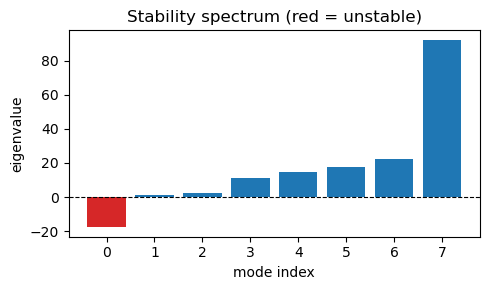

In [4]:
r = jnp.ones(N_COM)
chi_s = jnp.zeros(N_COM)
J = compute_jacobian(N_COM, BETA, chi, chi_s, r)
eigenvalues, eigenvectors, n_unstable = stability_analysis(J)

print(f'Number of unstable modes: {int(n_unstable)}')
print(f'Eigenvalues: {np.array(eigenvalues).round(2)}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(N_COM), eigenvalues, color=['tab:red' if e < 0 else 'tab:blue' for e in eigenvalues])
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('mode index')
ax.set_ylabel('eigenvalue')
ax.set_title('Stability spectrum (red = unstable)')
fig.tight_layout()
plt.show()

## 3. Run the simulation

Save periodic snapshots for phase analysis and animation.

In [5]:
c0 = generate_initial_conditions(N_COM, N_GRID, beta=BETA, noise_strength=0.01, key=k2)
params = build_params(chi, N_COM, beta=BETA, lmbda=LMBDA, dt=DT)

print(f'Initial field shape: {c0.shape}')
print(f'Mean volume fraction per component: {float(c0.mean()):.4f}')

Initial field shape: (8, 64, 64)
Mean volume fraction per component: 0.1111


In [6]:
%%time
c_final, snapshots = simulate_with_snapshots(
    c0, params, N_GRID, N_STEPS, save_every=SAVE_EVERY, progress_bar=True,
)
jax.block_until_ready(c_final)
print(f'Snapshots shape: {snapshots.shape}  (frames, components, Nx, Ny)')

Snapshots shape: (10, 8, 64, 64)  (frames, components, Nx, Ny)
CPU times: user 1min 19s, sys: 7.35 s, total: 1min 26s
Wall time: 46.6 s


## 4. Visualise the final state

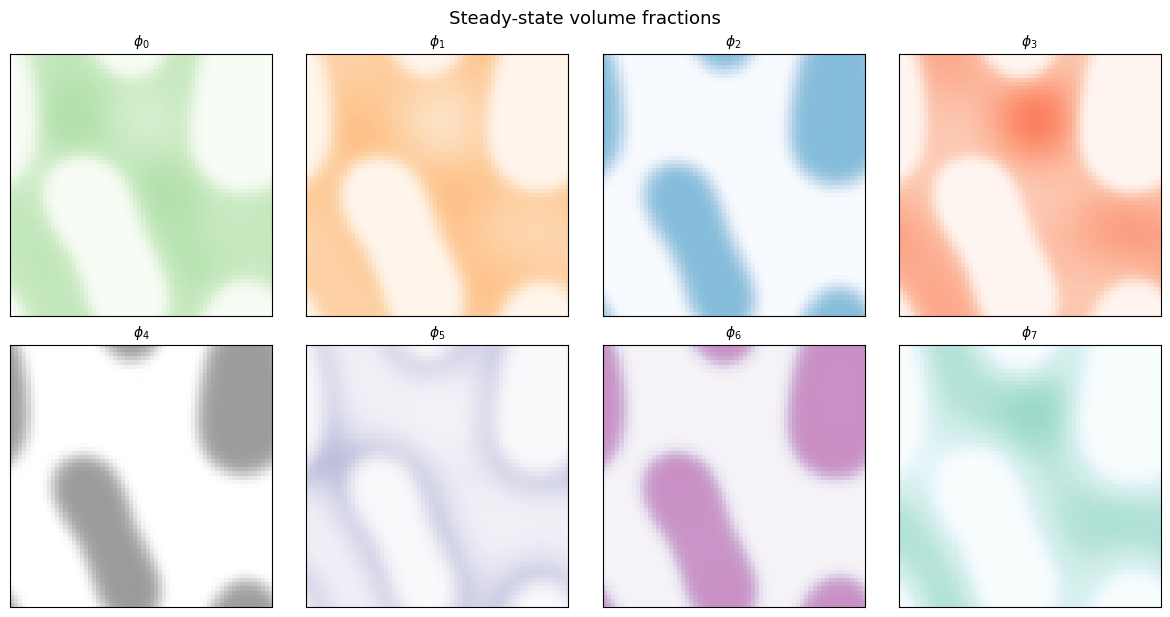

In [7]:
fig, _ = plot_volume_fractions(c_final, ncols=4, vmax=0.75)
fig.suptitle('Steady-state volume fractions', y=1.02, fontsize=13)
plt.show()

### Phase identification

`analyse_snapshot` runs PCA-based phase counting followed by K-means
clustering to assign each grid point to a phase and compute partition
ratios.

Detected phases: 2


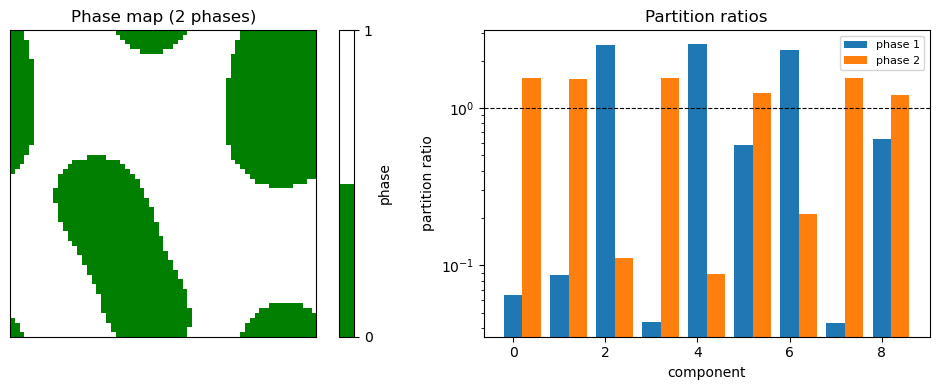

In [8]:
result = analyse_snapshot(np.array(c_final))
print(f"Detected phases: {result['n_phases']}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_phase_map(result['labels'], result['n_phases'], ax=axes[0])
axes[0].set_title(f"Phase map ({result['n_phases']} phases)")
plot_partition_ratios(result['partitions'], ax=axes[1])
axes[1].set_title('Partition ratios')
fig.tight_layout()
plt.show()

## 5. Movie of the evolution

Map the first three components to RGB and write `evolution.mp4`.

In [9]:
snaps = np.array(snapshots)
n_frames = snaps.shape[0]

def make_rgb(frame):
    """Map the first 3 components to an RGB image, normalised per-channel."""
    rgb = np.stack([frame[i] for i in range(3)], axis=-1)
    lo = rgb.min(axis=(0, 1), keepdims=True)
    hi = rgb.max(axis=(0, 1), keepdims=True)
    return np.clip((rgb - lo) / (hi - lo + 1e-12), 0, 1)

fig_mov, ax_mov = plt.subplots(figsize=(5, 5))
im_mov = ax_mov.imshow(make_rgb(snaps[0]), origin='lower', interpolation='bilinear')
time_text = ax_mov.set_title(f'step 0 / {N_STEPS}')
ax_mov.set_xticks([])
ax_mov.set_yticks([])

def update(i):
    im_mov.set_data(make_rgb(snaps[i]))
    ax_mov.set_title(f'step {(i + 1) * SAVE_EVERY:,} / {N_STEPS:,}')
    return [im_mov]

anim = animation.FuncAnimation(
    fig_mov, update, frames=n_frames, interval=100, blit=True,
)
plt.close(fig_mov)

In [10]:
movie_path = os.path.join(os.path.dirname(os.getcwd()), 'evolution.mp4')
try:
    anim.save(movie_path, writer='ffmpeg', fps=15, dpi=150)
    print(f'Movie saved to {movie_path}')
except Exception as e:
    print(f'ffmpeg not available ({e}); showing inline HTML5 video instead.')
    movie_path = None

Movie saved to /Users/jordanshivers/Box Sync/NewLab/phase_separation/notebooks/evolution.mp4


In [11]:
HTML(anim.to_html5_video())

### Filmstrip view

A static summary showing selected time points side by side.

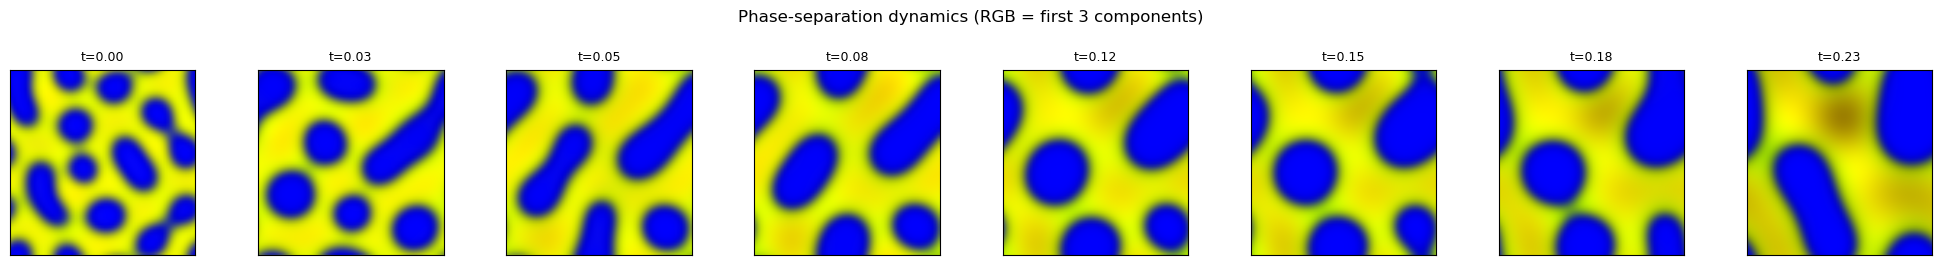

In [12]:
n_panels = min(8, n_frames)
indices = np.linspace(0, n_frames - 1, n_panels, dtype=int)

fig, axes = plt.subplots(1, n_panels, figsize=(2.5 * n_panels, 2.5))
for ax, idx in zip(axes, indices):
    ax.imshow(make_rgb(snaps[idx]), origin='lower', interpolation='bilinear')
    ax.set_title(f't={idx * SAVE_EVERY * DT:.2f}', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle('Phase-separation dynamics (RGB = first 3 components)', y=1.04, fontsize=12)
fig.tight_layout()
plt.show()

## 6. Differentiability

Differentiate the variance of the final field with respect to `c0`.

In [13]:
SHORT_STEPS = 1_000

@jax.jit
def loss_fn(c0_in):
    c_out = simulate(c0_in, params, N_GRID, SHORT_STEPS)
    return jnp.var(c_out)

grad_fn = jax.grad(loss_fn)

In [14]:
%%time
grad_c0 = grad_fn(c0)
jax.block_until_ready(grad_c0)

print(f'Gradient shape: {grad_c0.shape}')
print(f'Gradient magnitude (L2): {float(jnp.linalg.norm(grad_c0)):.6e}')

Gradient shape: (8, 64, 64)
Gradient magnitude (L2): 2.245903e-04
CPU times: user 4.78 s, sys: 857 ms, total: 5.64 s
Wall time: 2.99 s


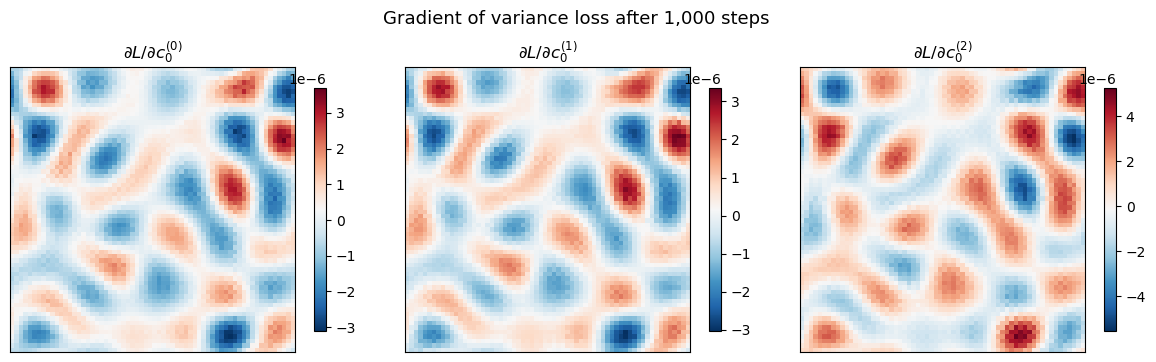

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for idx, (ax, title) in enumerate(zip(axes, [r'$\partial L / \partial c_0^{(0)}$',
                                              r'$\partial L / \partial c_0^{(1)}$',
                                              r'$\partial L / \partial c_0^{(2)}$'])):
    im = ax.imshow(grad_c0[idx], cmap='RdBu_r', origin='lower')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f'Gradient of variance loss after {SHORT_STEPS:,} steps', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()